# SCAN Compositional Interference (CI) demo

One representative checkpoint from the ACS paper's Section 3 SCAN sweep: `d_model=12`, `8%` training coverage, `seed=42` (10-layer toy decoder-only Transformer, `n_heads=4`, `d_ff=48`).

This notebook reproduces the paper's three diagnostic plots for this checkpoint by calling the **exact plotting functions** from `he_probe/analysis_atomic_avg.py` (not a reimplementation), then adds a demo block that prints the SCAN examples CI ranks as most likely to fail, from highest CI (most interference → predicted hardest) to lowest, alongside whether the model actually got each one right.

`d_model=12` is used here (rather than the smallest `d_model=8` checkpoint) because CI's signal is visibly cleaner once the model isn't capacity-starved: at `d_model=8` the model is only 47% accurate and the curves are noisy; at `d_model=12` it's 96% accurate and the cumulative/noncumulative curves are smooth and near-monotonic, and the error-recall curve clears the diagonal by ~8x more (AUC-above-diagonal 0.224 vs. 0.029).

It needs no GPU and does not reload the trained model — everything runs off the checkpoint's already-computed per-example table (`demo_data/size_p8_dmodel12/layer6_test_scores.csv`, the best layer selected by cumulative-coherence AUC) plus its saved atomic-concept representations (`..._atomic_reps_avg_train.pt`) and summary metrics (`best_layer_metrics.json`), all copied in from
`results_scan_paper_new_dev/size_p8/` in `Representational-Homomorphism-for-Transformer-Language-Models` (see `ACS/README.md`, Section III, for attribution).

**Run this notebook from `ACS/SCAN/`** so the `he_probe` package resolves.

In [1]:
import csv
import json
import subprocess
import sys
from pathlib import Path

from IPython.display import SVG, Image, display

# Make sure `he_probe` resolves as a package regardless of exactly where
# Jupyter's cwd ended up, as long as it's this notebook's own directory or below it.
NOTEBOOK_DIR = Path.cwd()
for _cand in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (_cand / "he_probe").is_dir():
        NOTEBOOK_DIR = _cand
        break
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# The real plotting functions from the analysis pipeline — imported, not reimplemented,
# so these figures are pixel-for-pixel what run_analysis_all_cumulative_coherence.sh produces.
from he_probe.analysis_atomic_avg import (
    plot_cumulative_curve,
    plot_noncumulative_curve,
    plot_error_recall_curve,
)

# Silence the library's per-permutation tqdm bar (1000 refresh lines otherwise) —
# purely cosmetic, does not touch the computation.
import he_probe.analysis_atomic_avg as _analysis_atomic_avg
_analysis_atomic_avg.tqdm = lambda it, *a, **k: it


def show_plot(svg_path):
    """Display a saved plot inline as PNG.

    The plotting functions above always save SVG. GitHub's notebook renderer (and some
    other viewers) refuses to render `image/svg+xml` outputs at all, so convert to PNG
    with rsvg-convert for display — falls back to showing the SVG directly if
    rsvg-convert isn't available (the underlying figure is identical either way).
    """
    svg_path = Path(svg_path)
    png_path = svg_path.with_suffix(".png")
    try:
        subprocess.run(
            ["rsvg-convert", "-o", str(png_path), str(svg_path)],
            check=True, capture_output=True,
        )
        display(Image(filename=str(png_path)))
    except (FileNotFoundError, subprocess.CalledProcessError):
        display(SVG(str(svg_path)))

In [2]:
DEMO_DIR = NOTEBOOK_DIR / "demo_data" / "size_p8_dmodel12"
CSV_PATH = DEMO_DIR / "layer6_test_scores.csv"
METRICS_PATH = DEMO_DIR / "best_layer_metrics.json"

OUT_DIR = NOTEBOOK_DIR / "demo_out"
OUT_DIR.mkdir(exist_ok=True)

with open(METRICS_PATH) as f:
    best_layer_metrics = json.load(f)

BEST_LAYER = best_layer_metrics["best_layer"]
BIN_WIDTH = 0.1  # matches --bin_width for this run (see demo_data/.../analysis_config.json)
N_PERMUTATIONS = 1000  # matches run_analysis_all_cumulative_coherence.sh; lower this for a quicker demo


def load_rows(csv_path):
    """Load per-example rows and attach CI = 1 - orthogonality.

    orthogonality here is the `cumulative_coherence` aggregation's `1 - CI` score
    (see example_orthogonality_score in analysis_atomic_avg.py): low orthogonality
    = concepts in the example are coherent = high interference = hard example.
    """
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            r["index"] = int(r["index"])
            r["n_primitives"] = int(r["n_primitives"])
            r["n_pairs"] = int(r["n_pairs"])
            r["correct"] = int(r["correct"])
            r["orthogonality"] = float(r["orthogonality"])
            r["CI"] = 1.0 - r["orthogonality"]
            rows.append(r)
    return rows


rows = load_rows(CSV_PATH)

print(
    f"Loaded {len(rows)} SCAN test examples "
    f"(seed {best_layer_metrics['seed']}, d_model={best_layer_metrics['d_model']}, "
    f"coverage={best_layer_metrics['size_variation_p']}%, best layer={BEST_LAYER})."
)
print(f"Overall exact-match accuracy: {best_layer_metrics['avg_acc']:.3f}")
print()
print("Precomputed summary metrics for this checkpoint's best layer (best_layer_metrics.json):")
for k in [
    "cumulative_auc",
    "predictive_power",
    "noncumulative_r",
    "noncumulative_p",
    "pr_auc_failure",
    "normalized_pr_auc_failure",
    "failure_rate",
    "perm_p_pr_auc",
    "error_recall_auc_above_diagonal",
]:
    print(f"  {k:32s} {best_layer_metrics[k]:.4f}")

Loaded 17310 SCAN test examples (seed 42, d_model=12, coverage=8%, best layer=6).
Overall exact-match accuracy: 0.963

Precomputed summary metrics for this checkpoint's best layer (best_layer_metrics.json):
  cumulative_auc                   0.8441
  predictive_power                 0.1233
  noncumulative_r                  0.8957
  noncumulative_p                  0.0005
  pr_auc_failure                   0.0970
  normalized_pr_auc_failure        0.0622
  failure_rate                     0.0371
  perm_p_pr_auc                    0.0000
  error_recall_auc_above_diagonal  0.2245


## 1. Cumulative accuracy vs. CI

Sort test examples by CI (equivalently, by `orthogonality` ascending); at each percentile cutoff, plot the mean accuracy of the examples at or below it. If CI predicts failure, this curve should start low (high-CI examples are hard) and rise toward the overall average as low-CI examples are added — the shaded band is the permutation-test null envelope.

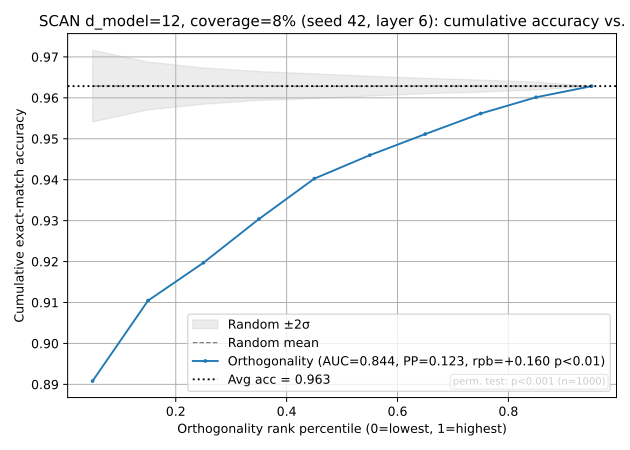

AUC=0.844  predictive_power=0.123  point-biserial r=0.160 (p=1.6e-99)


In [3]:
cumulative_title = (
    f"SCAN d_model=12, coverage=8% (seed 42, layer {BEST_LAYER}): "
    f"cumulative accuracy vs. CI"
)
cumulative_metrics = plot_cumulative_curve(
    rows,
    title=cumulative_title,
    savepath=str(OUT_DIR / "cumulative.svg"),
    bin_width=BIN_WIDTH,
    n_permutations=N_PERMUTATIONS,
)
show_plot(OUT_DIR / "cumulative.svg")
print(
    f"AUC={cumulative_metrics['auc']:.3f}  "
    f"predictive_power={cumulative_metrics['predictive_power']:.3f}  "
    f"point-biserial r={cumulative_metrics['pbc']:.3f} (p={cumulative_metrics['pbc_p']:.2g})"
)

## 2. Noncumulative accuracy vs. CI

Same sort, but binned (not cumulative): mean accuracy within each CI percentile bin on its own, showing whether accuracy trends monotonically with CI rather than just in aggregate.

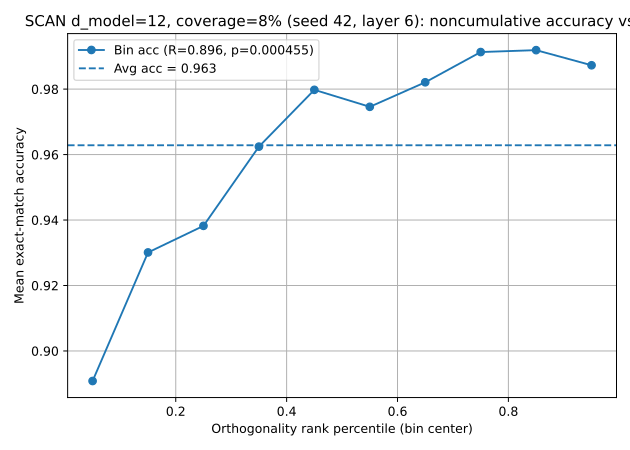

Pearson r=0.896 (p=0.00046), avg_acc=0.963


In [4]:
noncumulative_title = (
    f"SCAN d_model=12, coverage=8% (seed 42, layer {BEST_LAYER}): "
    f"noncumulative accuracy vs. CI"
)
noncumulative_stats = plot_noncumulative_curve(
    rows,
    title=noncumulative_title,
    savepath=str(OUT_DIR / "noncumulative.svg"),
    bin_width=BIN_WIDTH,
)
show_plot(OUT_DIR / "noncumulative.svg")
print(
    f"Pearson r={noncumulative_stats['r']:.3f} (p={noncumulative_stats['p']:.2g}), "
    f"avg_acc={noncumulative_stats['avg_acc']:.3f}"
)

## 3. Error-recall curve

Sort examples by CI descending (hardest-predicted first); X = fraction of the test set included, Y = fraction of all model errors captured. A curve above the diagonal means CI successfully front-loads the model's actual failures.

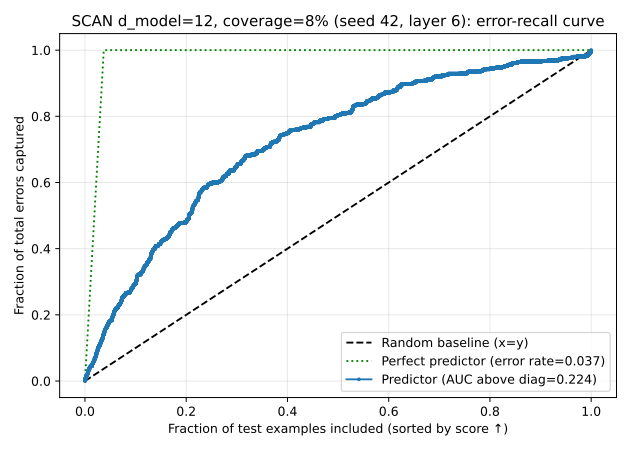

error_recall_auc_above_diagonal=0.224  error_rate=0.037


In [5]:
error_recall_title = (
    f"SCAN d_model=12, coverage=8% (seed 42, layer {BEST_LAYER}): error-recall curve"
)
error_recall_stats = plot_error_recall_curve(
    rows,
    title=error_recall_title,
    savepath=str(OUT_DIR / "error_recall.svg"),
)
show_plot(OUT_DIR / "error_recall.svg")
print(
    f"error_recall_auc_above_diagonal={error_recall_stats['error_recall_auc_above_diagonal']:.3f}  "
    f"error_rate={error_recall_stats['error_rate']:.3f}"
)

## 4. Top 10 most challenging SCAN examples — demo of CI's effectiveness

The 10 test examples with the **highest CI** (lowest `orthogonality`, i.e. the atomic concepts in the command are least separable in this checkpoint's representation space) — CI's prediction for "most likely to fail" — listed from high CI to low CI, with the SCAN command, the gold action sequence, and whether the model actually got it right.

In [6]:
rows_by_ci_desc = sorted(rows, key=lambda r: r["CI"], reverse=True)
top10 = rows_by_ci_desc[:10]

overall_acc = sum(r["correct"] for r in rows) / len(rows)
top10_acc = sum(r["correct"] for r in top10) / len(top10)

print(f"Overall accuracy (all {len(rows)} test examples):            {overall_acc:.3f}")
print(f"Accuracy among the 10 highest-CI (hardest-predicted) examples: {top10_acc:.3f}")
print()
print(f"{'rank':>4}  {'CI':>7}  {'result':^7}  {'n_prim':>6}  command  ->  gold answer")
print("-" * 110)
for i, r in enumerate(top10, start=1):
    mark = "correct" if r["correct"] else "WRONG"
    print(f"{i:>4}  {r['CI']:>7.4f}  {mark:^7}  {r['n_primitives']:>6}  {r['input']}  ->  {r['output']}")

Overall accuracy (all 17310 test examples):            0.963
Accuracy among the 10 highest-CI (hardest-predicted) examples: 0.700

rank       CI  result   n_prim  command  ->  gold answer
--------------------------------------------------------------------------------------------------------------
   1   0.7592  correct       5  turn around right twice and turn right thrice  ->  I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT
   2   0.7592  correct       5  turn right twice and turn around right thrice  ->  I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT
   3   0.7592   WRONG        5  turn around right thrice and turn right twice  ->  I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIG